# Hand Gesture Classification

Building a hand gesture classification model using landmark data extracted by MediaPipe from the HaGRID dataset.

## Imports & Setup

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform, mode
import itertools
from sklearn.svm import SVC
from xgboost import XGBClassifier
# import cv2
# import mediapipe as mp
from collections import deque, Counter
import joblib


## Loading Data 

In [5]:
landmarks = pd.read_csv('Data\hand_landmarks_data.csv')

In [6]:
landmarks.head()

,x1,y1,z1,x2,y2,z2,x3,y3,z3,x4,...,x19,y19,z19,x20,y20,z20,x21,y21,z21,label
0,262.669968,257.304901,-3.649205e-07,257.417542,247.109055,0.004224,246.882957,241.716827,0.005798,236.384537,...,223.345093,255.490692,-0.020450,215.043365,258.114746,-0.024577,208.006393,259.608673,-0.026722,call
1,83.351778,346.059113,-2.345265e-07,81.925037,328.562347,-0.011102,90.080132,311.535248,-0.021096,95.641823,...,132.451618,341.794434,-0.038175,142.773582,342.829254,-0.037336,152.431698,343.015991,-0.036136,call
2,187.756977,260.235492,-2.417307e-07,195.460579,241.506035,-0.000184,207.259529,223.674339,-0.009687,215.413628,...,250.301010,268.602938,-0.044068,262.425133,271.276638,-0.040469,272.989952,272.272231,-0.038301,call
3,114.976696,331.594238,-1.233261e-07,114.503494,320.549957,-0.002824,116.636627,310.080994,-0.008911,117.685066,...,145.195450,329.357544,-0.027622,151.053200,329.712341,-0.027863,155.990364,329.548828,-0.027723,call
4,188.795288,141.727867,-1.622995e-07,188.520905,127.947464,-0.002884,191.982880,111.010563,-0.008115,192.552521,...,226.696396,132.263248,-0.025113,234.831741,130.684147,-0.024087,241.587769,128.477188,-0.023486,call


In [7]:
print(f"Data Shape: {landmarks.shape}")

Data Shape: (25675, 64)


In [8]:
print(landmarks['label'].value_counts())

label
three2             1653
palm               1649
four               1634
ok                 1592
stop_inverted      1567
call               1506
peace_inverted     1497
stop               1482
rock               1458
three              1456
peace              1441
like               1436
two_up_inverted    1371
two_up             1343
dislike            1295
one                1263
mute               1087
fist                945
Name: count, dtype: int64


## Data Visualisation

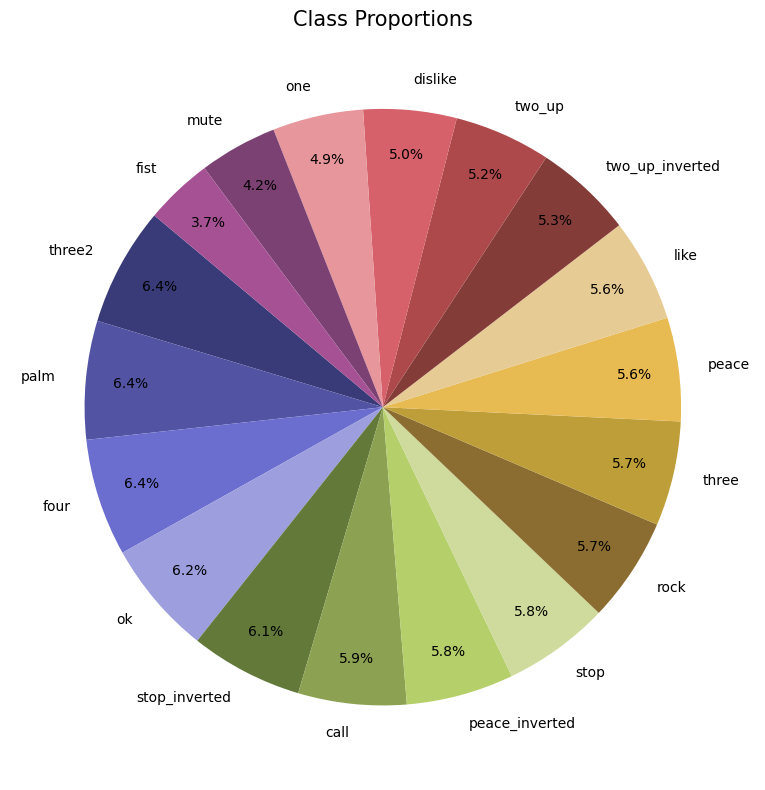

In [9]:
counts = landmarks['label'].value_counts()
colors = plt.cm.tab20b(range(len(counts)))
plt.figure(figsize=(8, 8))
plt.pie(counts.values, 
        labels=counts.index, 
        autopct='%1.1f%%',
        startangle=140,
        pctdistance=0.85,
        colors=colors) 

plt.title('Class Proportions', fontsize=15)
plt.tight_layout()
plt.show()

The Data is Balanced 

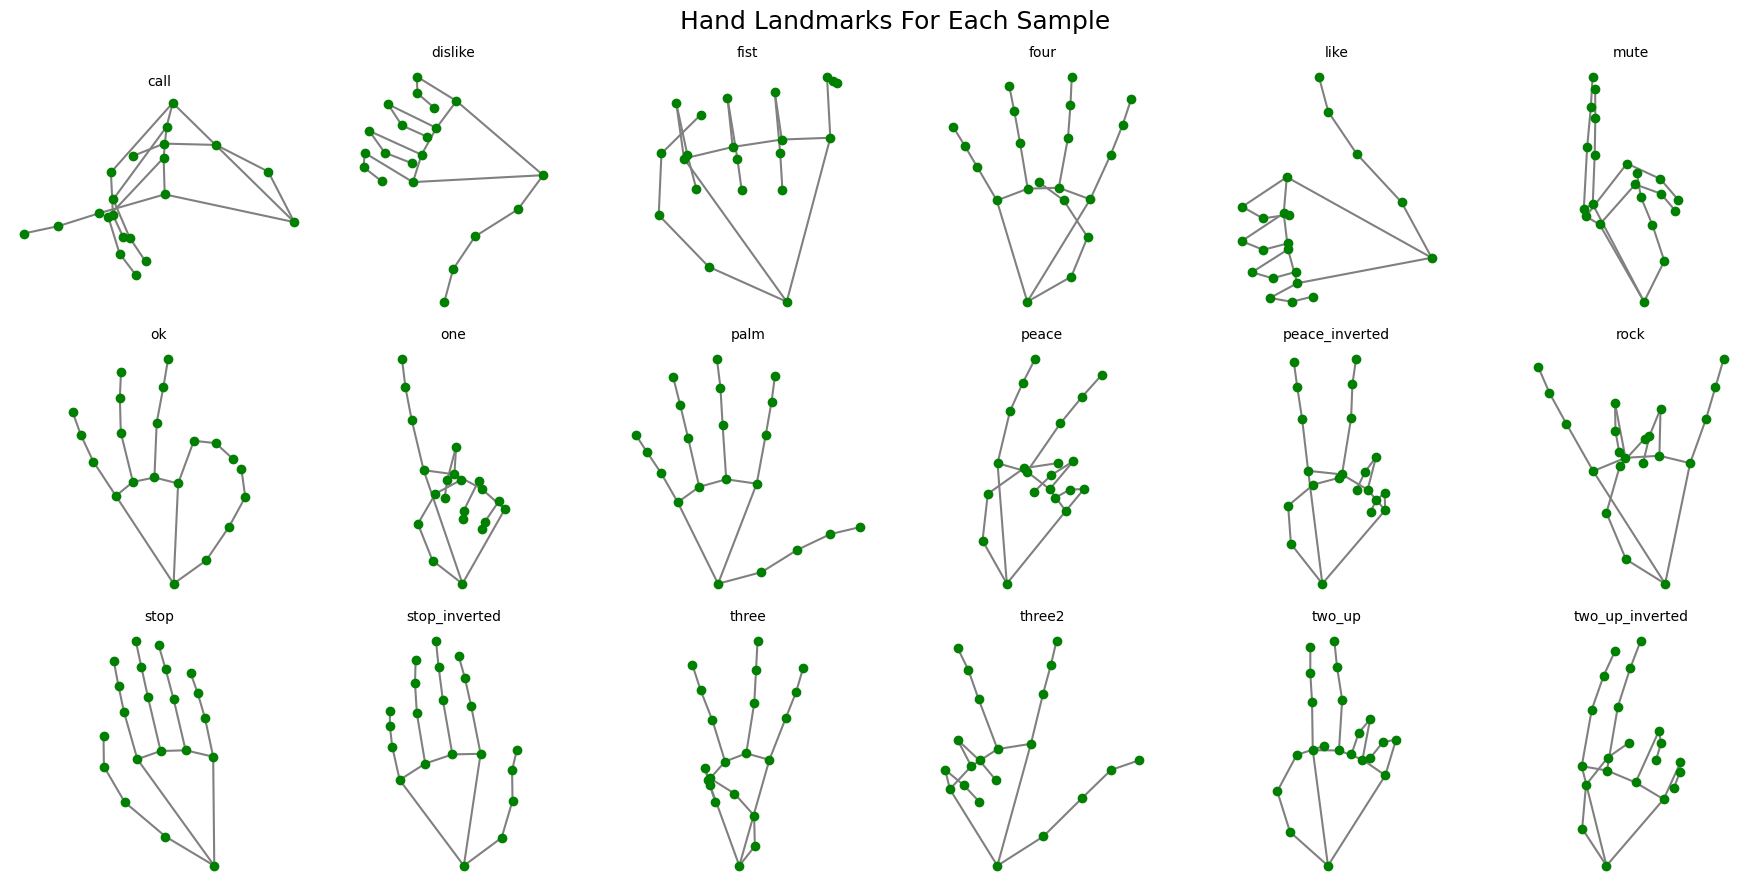

In [10]:
connections = [(0,1),(1,2),(2,3),(3,4),(0,5),(5,6),(6,7),(7,8),
    (5,9),(9,10),(10,11),(11,12),(9,13),(13,14),(14,15),(15,16),
    (13,17),(17,18),(18,19),(19,20),(0,17)]

def plot_hand(ax, points, title=""):
    for start, end in connections:
        ax.plot([points[start, 0], points[end, 0]], [points[start, 1], points[end, 1]], color='grey')

    ax.scatter(points[:, 0], points[:, 1], c='Green', zorder=2)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=10)
    ax.set_aspect('equal')
    ax.axis("off")

gestures = landmarks['label'].unique()
n = len(gestures)
n_cols = 6
n_rows = (n + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 9))
axes = axes.flatten()

for i, gesture in enumerate(gestures):
    sample = landmarks[landmarks['label'] == gesture].iloc[0]
    points = sample[:-1].values.reshape(-1, 3)
    plot_hand(axes[i], points, title=gesture)

plt.suptitle("Hand Landmarks For Each Sample", fontsize=18)
plt.tight_layout()
plt.show()

## Data Preprocessing

In [11]:
# Exract X, y from data and make lable encoding on X.
X = landmarks.drop(columns=['label']).values
y = landmarks['label'].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

- Normalize hand landmarks by translating to wrist origin and scaling by middle fingertip distance

In [12]:
def normalize_row(row):
    landmark = row.reshape(21, 3)   
    wrist = landmark[0, :2]         
    landmark[:, 0] -= wrist[0]
    landmark[:, 1] -= wrist[1]
    
    mid_tip = landmark[11, :2]
    scale = np.linalg.norm(mid_tip)
    if scale == 0:
        scale = 1
    landmark[:, 0] /= scale
    landmark[:, 1] /= scale
    return landmark.flatten()

## Feature Engineering

In [13]:
def compute_angle(a, b, c):
    ba = a - b
    bc = c - b
    cos_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-9)
    return np.clip(cos_angle, -1, 1)

- Calculate angles between finger joints

In [14]:
def finger_angles(row):
    landmark = row.reshape(21, 3)
    pts_2d = landmark[:, :2]
    finger_chains = [[0,1,2,3,4],[0,5,6,7,8],[0,9,10,11,12],[0,13,14,15,16],[0,17,18,19,20]]
    angles = []
    for chain in finger_chains:
        for k in range(len(chain)-2):
            a, b, c = chain[k], chain[k+1], chain[k+2]
            ang = compute_angle(pts_2d[a], pts_2d[b], pts_2d[c])
            angles.append(ang)        
    return np.array(angles)

- Calculate distances from each tip to the wrist

In [15]:
def tip_wrist_distances(row):
    landmark = row.reshape(21, 3)
    pts_2d = landmark[:, :2]
    tips = [4, 8, 12, 16, 20]
    wrist = pts_2d[0]
    dists = []
    for t in tips:
        d = np.linalg.norm(pts_2d[t] - wrist)
        dists.append(d)   
    return np.array(dists)

- Calculate distances between all pairs of finger

In [16]:
def cross_tip_distances(row):
    landmark = row.reshape(21, 3)
    pts_2d = landmark[:, :2]
    tips = [4, 8, 12, 16, 20]
    dists = []
    for i, j in itertools.combinations(tips, 2):
        d = np.linalg.norm(pts_2d[i] - pts_2d[j])
        dists.append(d)
    return np.array(dists)

- Extract thumb position and depth features relative to other key hand landmarks

In [17]:
def thumb_features(row):
    landmark = row.reshape(21, 3)
    pts = landmark[:, :2]  
    z   = landmark[:, 2]

    thumb_vs_index_base_y  = pts[4, 1] - pts[5, 1]
    thumb_to_index_base    = np.linalg.norm(pts[4] - pts[5])
    thumb_to_pinky_base    = np.linalg.norm(pts[4] - pts[17])
    z_thumb_vs_pinky_base  = z[4] - z[17]
    z_thumb_vs_index_base  = z[4] - z[5]
    z_thumb_vs_middle_base = z[4] - z[9]
    z_fingertips_vs_wrist  = z[[8, 12, 16, 20]].mean() - z[0]
    z_thumb_vs_other_tips  = z[4] - z[[8, 12, 16, 20]].mean()

    return np.array([thumb_vs_index_base_y, thumb_to_index_base,
            thumb_to_pinky_base, z_thumb_vs_pinky_base,
            z_thumb_vs_index_base, z_thumb_vs_middle_base,
            z_fingertips_vs_wrist, z_thumb_vs_other_tips])

- Compute mean and standard deviation of Z values for each finger to capture depth variation of each finger.

In [18]:
def z_stats(row):
    landmark = row.reshape(21, 3)
    # access the z axis
    z_vals = landmark[:, 2]
    finger_chains = [[0,1,2,3,4],[0,5,6,7,8],[0,9,10,11,12],[0,13,14,15,16],[0,17,18,19,20]]
    feats = []
    for chain in finger_chains:
        z_chain = z_vals[chain]
        feats.append(np.mean(z_chain))
        feats.append(np.std(z_chain))
    return np.array(feats)

- Combine all functions here to make new row 

In [19]:
def feature_engineering(row):
    features = np.concatenate([row.copy(), finger_angles(row), 
                               tip_wrist_distances(row), cross_tip_distances(row), 
                               z_stats(row), thumb_features(row)])
    return features

## Train-Dev-Test 

In [17]:
X_normalized = np.array([normalize_row(row) for row in X])
X_features = np.array([feature_engineering(row) for row in X_normalized])

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X_features, y, random_state=42, test_size=0.2, stratify=y)
X_test, X_dev, y_test, y_dev = train_test_split(X_test, y_test, random_state=42, test_size=0.5, stratify=y_test)

print(f"Train Data Shape: {X_train.shape}")
print(f"Dev Data Shape: {X_dev.shape}")
print(f"Test Data Shape: {X_test.shape}")

Train Data Shape: (20540, 111)
Dev Data Shape: (2568, 111)
Test Data Shape: (2567, 111)


## Model Training & Evaluation

#### Random Forest

In [19]:
rf_params = {'n_estimators'    : randint(100, 500),
            'max_depth'       : [None, 10, 20, 30],
            'min_samples_leaf': randint(1, 5),
            'max_features'    : ['sqrt', 'log2']}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params, n_iter=20, cv=5, scoring='accuracy',
    n_jobs=-1, verbose=1)

rf_search.fit(X_train, y_train)
print(f"Random Forest  best params : {rf_search.best_params_}")
print(f"Random Forest  best cv acc : {rf_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Random Forest  best params : {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 181}
Random Forest  best cv acc : 0.9881


In [20]:
y_pred = rf_search.predict(X_dev)
acc = accuracy_score(y_dev, y_pred)
print("Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_dev, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.985981308411215

Classification Report:
                 precision    recall  f1-score   support

           call       0.99      0.98      0.99       151
        dislike       1.00      0.99      1.00       129
           fist       1.00      1.00      1.00        94
           four       0.97      0.99      0.98       164
           like       0.99      1.00      0.99       144
           mute       0.95      0.99      0.97       108
             ok       0.99      0.99      0.99       159
            one       0.97      0.96      0.96       126
           palm       0.99      1.00      1.00       165
          peace       0.99      0.98      0.99       144
 peace_inverted       0.99      0.99      0.99       150
           rock       0.99      0.99      0.99       146
           stop       0.97      0.98      0.97       148
  stop_inverted       0.98      0.98      0.98       157
          three       0.99      0.96      0.97       146
         three2       1.00      0.9

#### SVM

In [21]:
# Svm Sensitive to Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_dev_sc = scaler.transform(X_dev)
X_test_sc  = scaler.transform(X_test)

In [22]:
svm_params = {'C': uniform(0.1, 50),
            'gamma' : ['scale', 'auto'],
            'kernel': ['rbf', 'poly']}

svm_search = RandomizedSearchCV(SVC(random_state=42, probability=True),
    svm_params, n_iter=20, cv=5, scoring='accuracy',random_state=42 ,n_jobs=-1,  verbose=1)

svm_search.fit(X_train_sc, y_train)
print(f"SVM best params : {svm_search.best_params_}")
print(f"SVM best cv acc : {svm_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
SVM best params : {'C': np.float64(30.15575058716044), 'gamma': 'auto', 'kernel': 'rbf'}
SVM best cv acc : 0.9856


In [23]:
y_pred = svm_search.predict(X_dev_sc)
acc = accuracy_score(y_dev, y_pred)
print("Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_dev, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.985202492211838

Classification Report:
                 precision    recall  f1-score   support

           call       0.99      0.99      0.99       151
        dislike       0.98      1.00      0.99       129
           fist       0.99      1.00      0.99        94
           four       0.98      0.99      0.98       164
           like       0.99      0.98      0.99       144
           mute       0.93      0.98      0.95       108
             ok       1.00      0.98      0.99       159
            one       0.98      0.95      0.96       126
           palm       0.99      0.98      0.99       165
          peace       0.99      0.97      0.98       144
 peace_inverted       0.99      0.99      0.99       150
           rock       0.99      0.99      0.99       146
           stop       0.96      0.99      0.98       148
  stop_inverted       0.99      1.00      0.99       157
          three       0.99      0.96      0.97       146
         three2       1.00      0.9

#### XGBoost

In [24]:
xgb_params = {'n_estimators': randint(100, 500),
            'max_depth': randint(3, 10),
            'learning_rate': uniform(0.01, 0.3),
            'subsample': uniform(0.6, 0.4),
            'colsample_bytree': uniform(0.6, 0.4),}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, n_jobs=-1,
                  eval_metric='mlogloss', verbosity=0),
                xgb_params, n_iter=20, cv=5, scoring='accuracy',
                n_jobs=-1, verbose=1, random_state=42)

xgb_search.fit(X_train, y_train)
print(f"XGBoost best params : {xgb_search.best_params_}")
print(f"XGBoost best cv acc : {xgb_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
XGBoost best params : {'colsample_bytree': np.float64(0.6923575302488596), 'learning_rate': np.float64(0.0823076398078035), 'max_depth': 6, 'n_estimators': 363, 'subsample': np.float64(0.6137554084460873)}
XGBoost best cv acc : 0.9889


In [25]:
y_pred = xgb_search.predict(X_dev)
acc = accuracy_score(y_dev, y_pred)
print("Accuracy:", acc)

print("\nClassification Report:")
print(classification_report(y_dev, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.9863707165109035

Classification Report:
                 precision    recall  f1-score   support

           call       0.99      0.98      0.99       151
        dislike       1.00      0.99      1.00       129
           fist       1.00      1.00      1.00        94
           four       0.97      0.99      0.98       164
           like       0.99      1.00      1.00       144
           mute       0.95      0.99      0.97       108
             ok       0.99      0.99      0.99       159
            one       0.97      0.96      0.96       126
           palm       1.00      1.00      1.00       165
          peace       0.97      0.98      0.98       144
 peace_inverted       0.99      0.99      0.99       150
           rock       0.99      0.99      0.99       146
           stop       0.97      0.99      0.98       148
  stop_inverted       0.99      0.99      0.99       157
          three       0.99      0.95      0.97       146
         three2       1.00      0.

## MLflow – Experiment Tracking

In [ ]:
# Import MLflow utilities
import mlflow
from mlflow_utils import (
    setup_experiment,
    run_experiment,
    log_sklearn_model,
    log_xgboost_model,
    log_model_comparison_chart,
    register_best_model,
)

In [ ]:
# Set up the experiment
experiment_id = setup_experiment("hand-gesture-classification")

### Run 1 – Random Forest

In [ ]:
rf_run_id = run_experiment(
    run_name        = "random-forest-randomized-search",
    model_tag       = "Random Forest",
    search_cv       = rf_search,
    X_train=X_train, X_dev=X_dev, X_test=X_test,
    y_train=y_train, y_dev=y_dev, y_test=y_test,
    label_encoder   = label_encoder,
    log_model_fn    = log_sklearn_model,
    csv_path        = "Data/hand_landmarks_data.csv",
)


### Run 2 – SVM

In [ ]:
# SVM requires the scaled versions of X
svm_run_id = run_experiment(
    run_name        = "svm-randomized-search",
    model_tag       = "SVM",
    search_cv       = svm_search,
    X_train=X_train, X_dev=X_dev, X_test=X_test,
    y_train=y_train, y_dev=y_dev, y_test=y_test,
    label_encoder   = label_encoder,
    log_model_fn    = log_sklearn_model,
    X_dev_for_pred  = X_dev_sc,
    X_test_for_pred = X_test_sc,
    extra_tags      = {"scaled": "StandardScaler"},
)

### Run 3 – XGBoost

In [ ]:
xgb_run_id = run_experiment(
    run_name        = "xgboost-randomized-search",
    model_tag       = "XGBoost",
    search_cv       = xgb_search,
    X_train=X_train, X_dev=X_dev, X_test=X_test,
    y_train=y_train, y_dev=y_dev, y_test=y_test,
    label_encoder   = label_encoder,
    log_model_fn    = log_xgboost_model,
)

### Model Comparison Chart

In [ ]:
import mlflow

results = [
    {
        "model"        : "Random Forest",
        "cv_accuracy"  : round(rf_search.best_score_, 4),
        "dev_accuracy" : accuracy_score(y_dev,  rf_search.predict(X_dev)),
        "test_accuracy": accuracy_score(y_test, rf_search.predict(X_test)),
        "dev_macro_f1" : f1_score(y_dev, rf_search.predict(X_dev), average="macro"),
    },
    {
        "model"        : "SVM",
        "cv_accuracy"  : round(svm_search.best_score_, 4),
        "dev_accuracy" : accuracy_score(y_dev,  svm_search.predict(X_dev_sc)),
        "test_accuracy": accuracy_score(y_test, svm_search.predict(X_test_sc)),
        "dev_macro_f1" : f1_score(y_dev, svm_search.predict(X_dev_sc), average="macro"),
    },
    {
        "model"        : "XGBoost",
        "cv_accuracy"  : round(xgb_search.best_score_, 4),
        "dev_accuracy" : accuracy_score(y_dev,  xgb_search.predict(X_dev)),
        "test_accuracy": accuracy_score(y_test, xgb_search.predict(X_test)),
        "dev_macro_f1" : f1_score(y_dev, xgb_search.predict(X_dev), average="macro"),
    },
]

# Log comparison chart inside a dedicated comparison run
mlflow.set_experiment("hand-gesture-classification")
with mlflow.start_run(run_name="model-comparison-summary"):
    log_model_comparison_chart(results)


### Register Best Model – XGBoost

In [ ]:
# Register the winning XGBoost model in the MLflow Model Registry
registered = register_best_model(
    run_id          = xgb_run_id,
    registered_name = "hand-gesture-xgboost-champion",
)
print(f"Model version: {registered.version}")


### Saving models

In [26]:
joblib.dump(rf_search,   "rf.pkl")
joblib.dump(svm_search,  "svm.pkl")
joblib.dump(xgb_search,  "xgb.pkl")

['xgb.pkl']

## Conclusion

| Model | CV Accuracy | Dev Accuracy | Macro F1 |
|---|---|---|---|
| Random Forest | 98.77% | 98.60% | 0.990 |
| SVM | 98.56% | 98.52% | 0.984 |
| **XGBoost**  | **98.89%** | **98.64%** | **0.990** |

**Best Model: XGBoost**
- Highest CV accuracy **(98.89%)** and dev accuracy **(98.64%)**
- Best hyperparameters: `n_estimators=363`, `max_depth=6`, `learning_rate=0.082`

## Test Set Prediction : XGBoost

In [26]:
y_test_pred = xgb_search.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
print(f'XGBoost Test Set Accuracy: {test_acc:.2%}')

print('\nClassification Report:')
print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))

XGBoost Test Set Accuracy: 98.91%

Classification Report:
                 precision    recall  f1-score   support

           call       0.99      0.99      0.99       150
        dislike       1.00      1.00      1.00       130
           fist       0.99      0.98      0.98        95
           four       0.99      0.99      0.99       163
           like       0.99      0.99      0.99       143
           mute       0.98      0.96      0.97       109
             ok       0.99      0.99      0.99       159
            one       0.95      0.98      0.96       127
           palm       0.98      0.99      0.99       165
          peace       0.99      0.99      0.99       144
 peace_inverted       0.99      0.99      0.99       149
           rock       1.00      0.99      1.00       146
           stop       0.98      0.98      0.98       148
  stop_inverted       0.99      0.99      0.99       157
          three       1.00      0.99      1.00       145
         three2       0.99   

## Video


In [27]:
# Initialize MediaPipe tools outside the function to reduce resource consumption
mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

def run_gesture_recognition(model, label_encoder, video_source=0, output_name='output.mp4'):

    # Setup MediaPipe Hands
    hands = mp_hands.Hands(
        static_image_mode=False,
        max_num_hands=1,
        model_complexity=1,
        min_detection_confidence=0.6,
        min_tracking_confidence=0.6
    )

    window = deque(maxlen=10)
    cap = cv2.VideoCapture(video_source)

    if not cap.isOpened():
        print("Error: Could not open video source.")
        return

    # Video settings for maintenance and saving
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_name, fourcc, fps/2, (width, height))

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            frame = cv2.flip(frame, 1)
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            rgb.flags.writeable = False
            result = hands.process(rgb)
            rgb.flags.writeable = True

            label = "No hand"

            if result.multi_hand_landmarks:
                hand_landmarks = result.multi_hand_landmarks[0]

                # Extract landmarks
                lms = [[lm.x, lm.y, lm.z] for lm in hand_landmarks.landmark]
                row = np.array(lms, dtype=np.float32).flatten()

                features_63 = normalize_row(row)
                new_row = feature_engineering(features_63)

                # Prediction using the passed model
                prediction = model.predict(new_row.reshape(1, -1))
                current_label = label_encoder.inverse_transform(prediction)[0]

                # Result smoothing
                window.append(current_label)
                label = Counter(window).most_common(1)[0][0]

                # Draw landmarks (two layers as in original code)
                for color, thickness, radius in [((230, 0, 0), 5, 3), ((255, 140, 0), 5, 2)]:
                    mp_draw.draw_landmarks(
                        frame, hand_landmarks, mp_hands.HAND_CONNECTIONS,
                        mp_draw.DrawingSpec(color=color, thickness=thickness, circle_radius=radius),
                        mp_draw.DrawingSpec(color=(255, 255, 255), thickness=1 if radius==2 else 2)
                    )

            # Draw transparent background and text
            label_text = f"{label}"
            (text_w, text_h), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.9, 2)
            overlay = frame.copy()
            cv2.rectangle(overlay, (10, 10), (10 + text_w + 36, 10 + text_h + 24), (0, 0, 0), -1)
            cv2.addWeighted(overlay, 0.4, frame, 0.6, 0, frame)
            cv2.putText(frame, label_text, (28, 10 + 12 + text_h), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 216, 173), 2, cv2.LINE_AA)

            out.write(frame)
            cv2.imshow("Hand Gesture Recognition", frame)

            # ESC to exit
            if cv2.waitKey(1) & 0xFF == 27: 
                break
    finally:
        hands.close()
        cap.release()
        out.release()
        cv2.destroyAllWindows()

In [28]:
run_gesture_recognition(model=xgb_search, label_encoder=label_encoder)

c:\Users\win11\anaconda3\envs\hand_landmarks\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
c:\Users\win11\anaconda3\envs\hand_landmarks\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
c:\Users\win11\anaconda3\envs\hand_landmarks\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated